<h1 style="text-align: center; font-weight: bold;">DATA PREPROCESSING</h1>

## Loading Dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [2]:
# Load training dataset
train = pd.read_csv('../data/train.csv')

# Also load test dataset to subject it to the same pipeline
test = pd.read_csv('../data/test.csv')

train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")

Training set shape: (140700, 20)
Test set shape: (93800, 19)


## Processing Binary Categorical Features

In [4]:
binary_cols = ['Gender', 'Working Professional or Student', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

# Check values in binary columns
for col in binary_cols:
    print(f"'{col}': {train[col].unique()}")

'Gender': ['Female' 'Male']
'Working Professional or Student': ['Working Professional' 'Student']
'Have you ever had suicidal thoughts ?': ['No' 'Yes']
'Family History of Mental Illness': ['No' 'Yes']


In [5]:
# Binary mapping
gender_map = {'Male': 1,
              'Female': 0}
suicidal_map = {'Yes': 1,
               'No': 0}
working_map = {'Working Professional': 1,
                           'Student': 0}
family_history_map = {'Yes': 1,
                      'No': 0}

# Convert binary categorical features to numerical
for dataset in [train, test]:
    dataset['Gender'] = dataset['Gender'].map(gender_map)
    dataset['Have you ever had suicidal thoughts ?'] = dataset['Have you ever had suicidal thoughts ?'].map(suicidal_map)
    dataset['Working Professional or Student'] = dataset['Working Professional or Student'].map(working_map)
    dataset['Family History of Mental Illness'] = dataset['Family History of Mental Illness'].map(family_history_map)
    
# Double check
for col in binary_cols:
    print("Train: ", train[col].value_counts())
    print("Test: ", test[col].value_counts())
    print("\n")

Train:  Gender
1    77464
0    63236
Name: count, dtype: int64
Test:  Gender
1    51262
0    42538
Name: count, dtype: int64


Train:  Working Professional or Student
1    112799
0     27901
Name: count, dtype: int64
Test:  Working Professional or Student
1    75028
0    18772
Name: count, dtype: int64


Train:  Have you ever had suicidal thoughts ?
0    71138
1    69562
Name: count, dtype: int64
Test:  Have you ever had suicidal thoughts ?
0    47375
1    46425
Name: count, dtype: int64


Train:  Family History of Mental Illness
0    70758
1    69942
Name: count, dtype: int64
Test:  Family History of Mental Illness
0    47118
1    46682
Name: count, dtype: int64




## Processing Categorical Features with Multiple Categories

### `Sleep Duration`

In [6]:
# Unique values in Sleep Duration
print(train['Sleep Duration'].unique())

['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']


In [7]:
# Mapping for Sleep Duration
sleep_map = {"More than 8 hours":9,
        'Less than 5 hours':4,
        '5-6 hours':5.5,
        '7-8 hours':7.5,
        '1-2 hours':1.5,
        '6-8 hours':7,
        '4-6 hours':5,
        '6-7 hours':6.5,
        '10-11 hours':10.5,
        '8-9 hours':8.5,
        '9-11 hours':10,
        '2-3 hours':2.5,
        '3-4 hours':3.5,
        '4-5 hours':4.5,
        '9-6 hours':7.5,
        '1-3 hours':2,
        '1-6 hours':3.5,
        '8 hours':8,
        '10-6 hours':8,
        '3-6 hours':4.5,
        '9-5':7,
        '9-5 hours':7,
}

# Convert Sleep Duration to numerical
for dataset in [train, test]:
    dataset['Sleep Duration'] = dataset['Sleep Duration'].map(sleep_map)
    
# Double check
for dataset in [train, test]:
    print(f"Values in Sleep Duration: {dataset['Sleep Duration'].unique()}")

Values in Sleep Duration: [ 9.   4.   5.5  7.5  nan  1.5  7.   5.   6.5 10.5  8.5 10.   2.5  3.5
  4.5  2.   8. ]
Values in Sleep Duration: [ 4.   7.5  9.   5.5  nan  7.   6.5  3.5  8.5  4.5  1.5  8.   2.   5.
  2.5 10. ]


### `Dietary Habits`

In [8]:
# Unique values in Dietary Habits
print(train['Dietary Habits'].unique())

['Healthy' 'Unhealthy' 'Moderate' 'Yes' 'Pratham' 'BSc' 'Gender' '3'
 'More Healthy' 'Less than Healthy' 'Mihir' '1.0' 'Hormonal' 'Electrician'
 nan 'No Healthy' 'Less Healthy' 'M.Tech' 'Vegas' 'No' 'Male' 'Indoor'
 'Class 12' '2']


In [9]:
# Mapping for Dietary Habits
diet_map = {'More Healthy':'Healthy',
    'Healthy':'Healthy',
    'Less than Healthy':'Less Healthy',
    'Less Healthy':'Less Healthy',
    'Moderate':'Moderate',
    'Unhealthy':'Unhealthy',   
    'No Healthy':'Unhealthy',
}

# Convert Dietary Habits to numerical
for dataset in [train, test]:
    dataset['Dietary Habits'] = dataset['Dietary Habits'].map(diet_map)
    
# Double check
for dataset in [train, test]:
    print(f"Values in Dietary Habits: {dataset['Dietary Habits'].unique()}")

Values in Dietary Habits: ['Healthy' 'Unhealthy' 'Moderate' nan 'Less Healthy']
Values in Dietary Habits: ['Moderate' 'Healthy' 'Unhealthy' nan 'Less Healthy']


### `Degree`

In [10]:
# Unique values in Degree
print(train['Degree'].unique())

['BHM' 'LLB' 'B.Pharm' 'BBA' 'MCA' 'MD' 'BSc' 'ME' 'B.Arch' 'BCA' 'BE'
 'MA' 'B.Ed' 'B.Com' 'MBA' 'M.Com' 'MHM' 'BA' 'Class 12' 'M.Tech' 'PhD'
 'M.Ed' 'MSc' 'B.Tech' 'LLM' 'MBBS' 'M.Pharm' 'UX/UI Designer' 'MPA' 'BH'
 'Nalini' 'BEd' 'B.Sc' 'Veda' 'Bhopal' 'S.Tech' 'Degree' '20' 'Class 11'
 'H_Pharm' 'M' 'P.Com' 'BPharm' 'Business Analyst' 'M.Arch' 'LL.Com'
 'Data Scientist' 'MPharm' 'L.Ed' 'P.Pharm' 'Kalyan' 'Unite' 'BArch'
 'HR Manager' 'Badhya' 'S.Pharm' 'LLBA' 'Vrinda' 'M. Business Analyst'
 'Bhavesh' '0' 'LLCom' '29' 'MTech' 'Vivaan' 'BPA' 'Plumber' '5.61' 'Brit'
 'B.03' 'Ritik' '5.56' 'MEd' 'B' 'B BA' '7.06' 'B.B.Arch' 'ACA' 'Brithika'
 'CGPA' '24' 'M_Tech' 'Pihu' 'BB' 'Jhanvi' 'LLTech' 'Aarav' 'Entrepreneur'
 '8.56' 'LHM' 'Lata' 'S.Arch' 'Marsh' 'HCA' '5.88' 'B.Student' 'LL B.Ed'
 'M.S' 'Navya' 'Mahika' nan 'K.Ed' 'B.3.79' 'Mthanya'
 'Working Professional' 'Esha' 'LLS' 'LLEd' 'E.Tech' 'Doctor' 'N.Pharm'
 'LCA' 'B B.Com' 'RCA' 'Mihir' 'Advait']


In [11]:
# Mapping for Degree
degree = {
    "BCom": "B.Com", "B.Com": "B.Com", "B.Comm": "B.Com", "B BCom": "B.Com", "B B.Com": "B.Com",
    "B.Tech": "B.Tech", "BTech": "B.Tech", "B.T": "B.Tech",
    "BSc": "B.Sc", "B.Sc": "B.Sc", "Bachelor of Science": "B.Sc",
    "BArch": "B.Arch", "B.Arch": "B.Arch",
    "BA": "B.A", "B.A": "B.A",
    "BBA": "BBA", "BB": "BBA", "B BA": "BBA", "B.B.Arch": "BBA",
    "BCA": "BCA",
    "BE": "BE",
    "BEd": "B.Ed", "B.Ed": "B.Ed",
    "BPharm": "B.Pharm", "B.Pharm": "B.Pharm",
    "BHM": "BHM",
    "LLB": "LLB", "LL B": "LLB", "LL BA": "LLB", "LL.Com": "LLB", "LLCom": "LLB",
    "MCom": "M.Com", "M.Com": "M.Com",
    "M.Tech": "M.Tech", "MTech": "M.Tech", "M.T": "M.Tech", "M_Tech": "M.Tech",
    "MSc": "M.Sc", "M.Sc": "M.Sc", "Master of Science": "M.Sc",
    "MBA": "MBA",
    "MCA": "MCA",
    "MD": "MD",
    "ME": "ME",
    "MEd": "M.Ed", "M.Ed": "M.Ed",
    "MArch": "M.Arch", "M.Arch": "M.Arch",
    "MPharm": "M.Pharm", "M.Pharm": "M.Pharm",
    "MA": "MA", "M.A": "MA",
    "MPA": "MPA",
    "LLM": "LLM",
    "PhD": "PhD",
    "MBBS": "MBBS",
    "CA": "CA",
    "Class 12": "Class 12", "12th": "Class 12",
    "Class 11": "Class 11", "11th": "Class 11"
}

# Convert Degree to standardized categories
for dataset in [train, test]:
    dataset['Degree'] = dataset['Degree'].map(degree)
    
# Double check
for dataset in [train, test]:
    print(f"Values in Degree: {dataset['Degree'].unique()}")

Values in Degree: ['BHM' 'LLB' 'B.Pharm' 'BBA' 'MCA' 'MD' 'B.Sc' 'ME' 'B.Arch' 'BCA' 'BE'
 'MA' 'B.Ed' 'B.Com' 'MBA' 'M.Com' nan 'B.A' 'Class 12' 'M.Tech' 'PhD'
 'M.Ed' 'M.Sc' 'B.Tech' 'LLM' 'MBBS' 'M.Pharm' 'MPA' 'Class 11' 'M.Arch']
Values in Degree: ['LLB' 'B.Ed' 'B.Arch' 'B.Sc' 'BCA' 'B.Com' 'MA' 'B.A' 'BBA' 'Class 12'
 'MD' 'MBA' 'M.Ed' 'M.Pharm' 'BHM' 'LLM' 'PhD' 'M.Com' 'BE' 'MBBS'
 'B.Tech' 'ME' 'MCA' 'B.Pharm' nan 'M.Tech' 'M.Sc' 'M.Arch']


## Fill Structurally Missing Values

### `Academic Pressure` vs `Work Pressure` (dependent on `Working Professional or Student`)

In [12]:
# Number of missing values in Academic Pressure and Work Pressure
train[['Academic Pressure', 'Work Pressure']].isnull().sum()

Academic Pressure    112803
Work Pressure         27918
dtype: int64

In [13]:
# Fill Academic Pressure with 0 where Working Professional or Student is '1'
train.loc[(train['Working Professional or Student'] == 1) & (train['Academic Pressure'].isnull()), 'Academic Pressure'] = 0
test.loc[(test['Working Professional or Student'] == 1) & (test['Academic Pressure'].isnull()), 'Academic Pressure'] = 0

# and vice versa for Work Pressure
train.loc[(train['Working Professional or Student'] == 0) & (train['Work Pressure'].isnull()), 'Work Pressure'] = 0
test.loc[(test['Working Professional or Student'] == 0) & (test['Work Pressure'].isnull()), 'Work Pressure'] = 0

# Double check
print("Remaining missing values in train:")
print(train[['Academic Pressure', 'Work Pressure']].isnull().sum())
print("Remaining missing values in test:")
print(test[['Academic Pressure', 'Work Pressure']].isnull().sum())

Remaining missing values in train:
Academic Pressure     9
Work Pressure        20
dtype: int64
Remaining missing values in test:
Academic Pressure     7
Work Pressure        10
dtype: int64


### `Study Satisfaction` vs `Job Satisfaction` (dependent on `Working Professional or Student`)

In [14]:
# Number of missing values in Study Satisfaction and Job Satisfaction
train[['Study Satisfaction', 'Job Satisfaction']].isnull().sum()

Study Satisfaction    112803
Job Satisfaction       27910
dtype: int64

In [15]:
# Fill Study Satisfaction with 0 where Working Professional or Student is '1'
train.loc[(train['Working Professional or Student'] == 1) & (train['Study Satisfaction'].isnull()), 'Study Satisfaction'] = 0
test.loc[(test['Working Professional or Student'] == 1) & (test['Study Satisfaction'].isnull()), 'Study Satisfaction'] = 0

# and vice versa for Job Satisfaction
train.loc[(train['Working Professional or Student'] == 0) & (train['Job Satisfaction'].isnull()), 'Job Satisfaction'] = 0
test.loc[(test['Working Professional or Student'] == 0) & (test['Job Satisfaction'].isnull()), 'Job Satisfaction'] = 0

# Double check
print("Remaining missing values in train:")
print(train[['Study Satisfaction', 'Job Satisfaction']].isnull().sum())
print("Remaining missing values in test:")
print(test[['Study Satisfaction', 'Job Satisfaction']].isnull().sum())

Remaining missing values in train:
Study Satisfaction    10
Job Satisfaction      17
dtype: int64
Remaining missing values in test:
Study Satisfaction    8
Job Satisfaction      9
dtype: int64


### `Profession` (dependent on `Working Professional or Student`)

In [16]:
# Number of missing values in Profession
train['Profession'].isnull().sum()

np.int64(36630)

In [17]:
# Fill in Profession with 'Not Applicable' where Working Professional or Student is '0'
train.loc[(train['Working Professional or Student'] == 0) & (train['Profession'].isnull()), 'Profession'] = 'Not Applicable'
test.loc[(test['Working Professional or Student'] == 0) & (test['Profession'].isnull()), 'Profession'] = 'Not Applicable'

# Double check
print(f"Remaining missing values in train: {train['Profession'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Profession'].isnull().sum()}")

Remaining missing values in train: 8763
Remaining missing values in test: 5886


### `CGPA` (dependent on `Working Professional or Student`)

In [18]:
# Number of missing values in CGPA
train['CGPA'].isnull().sum()

np.int64(112802)

In [19]:
# Fill in CGPA with 0 where Working Professional or Student is '1'
train.loc[(train['Working Professional or Student'] == 1) & (train['CGPA'].isnull()), 'CGPA'] = 0
test.loc[(test['Working Professional or Student'] == 1) & (test['CGPA'].isnull()), 'CGPA'] = 0

# Double check
print(f"Remaining missing values in train: {train['CGPA'].isnull().sum()}")
print(f"Remaining missing values in test: {test['CGPA'].isnull().sum()}")

Remaining missing values in train: 9
Remaining missing values in test: 9


## Fill actual Missing Values

In [20]:
# Check missing values in the two datasets
print("Missing values in training set:\n", train.isnull().sum())
print("\nMissing values in test set:\n", test.isnull().sum())

Missing values in training set:
 id                                          0
Name                                        0
Gender                                      0
Age                                         0
City                                        0
Working Professional or Student             0
Profession                               8763
Academic Pressure                           9
Work Pressure                              20
CGPA                                        9
Study Satisfaction                         10
Job Satisfaction                           17
Sleep Duration                             20
Dietary Habits                             22
Degree                                   3375
Have you ever had suicidal thoughts ?       0
Work/Study Hours                            0
Financial Stress                            4
Family History of Mental Illness            0
Depression                                  0
dtype: int64

Missing values in test set:
 id  

In [21]:
# Check data types to see whether non-missing values are of correct types
print("Data types in training set:\n", train.dtypes)
print("\nData types in test set:\n", test.dtypes)

Data types in training set:
 id                                         int64
Name                                      object
Gender                                     int64
Age                                      float64
City                                      object
Working Professional or Student            int64
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                           float64
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                              

In [22]:
cols_w_missing = [col for col in train.columns if train[col].isnull().sum() > 0]
print(cols_w_missing)

['Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Financial Stress']


### `Profession`

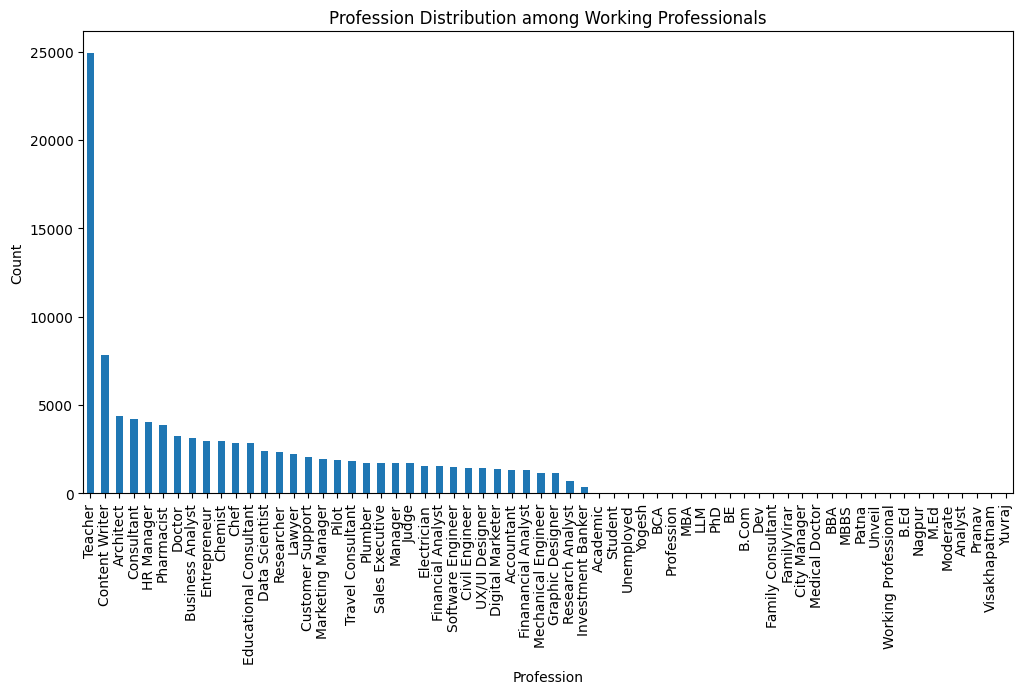

In [23]:
# Distribution of Profession in Working Professionals only
profesison_counts = train[train['Working Professional or Student'] == 1]['Profession'].value_counts()
plt.figure(figsize=(12,6))
profesison_counts.plot(kind='bar')
plt.title("Profession Distribution among Working Professionals")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.show()

In [24]:
# Fill missing data in profession with mode imputation for working professionals
mode_profession = train[train['Working Professional or Student'] == 1]['Profession'].mode()[0]
train.loc[(train['Working Professional or Student'] == 1) & (train['Profession'].isnull()), 'Profession'] = mode_profession
test.loc[(test['Working Professional or Student'] == 1) & (test['Profession'].isnull()), 'Profession'] = mode_profession

# Double check
print(f"Remaining missing values in train: {train['Profession'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Profession'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


### `Academic Pressure` and `Work Pressure`

<Figure size 1200x600 with 0 Axes>

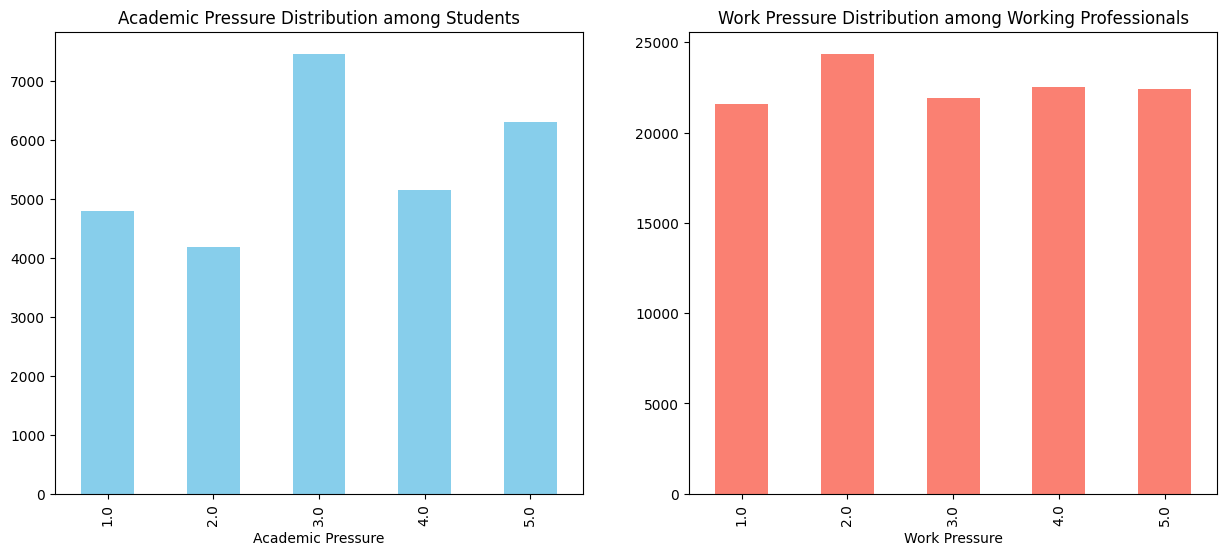

In [25]:
# Distribution of Academic Pressure among Students and Work Pressure among Working Professionals
student_academic_pressure = train[train['Working Professional or Student'] == 0]['Academic Pressure'].value_counts().sort_index()
working_work_pressure = train[train['Working Professional or Student'] == 1]['Work Pressure'].value_counts().sort_index()

plt.figure(figsize=(12,6))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
student_academic_pressure.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Academic Pressure Distribution among Students")
working_work_pressure.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("Work Pressure Distribution among Working Professionals")

plt.show()

In [26]:
# Fill Academic Pressure with mode imputation for students
mode_academic_pressure = train[train['Working Professional or Student'] == 0]['Academic Pressure'].mode()[0]
train.loc[(train['Working Professional or Student'] == 0) & (train['Academic Pressure'].isnull()), 'Academic Pressure'] = mode_academic_pressure
test.loc[(test['Working Professional or Student'] == 0) & (test['Academic Pressure'].isnull()), 'Academic Pressure'] = mode_academic_pressure

# and Work pressure with mean imputation for working professionals
mean_work_pressure = train[train['Working Professional or Student'] == 1]['Work Pressure'].mean()
train.loc[(train['Working Professional or Student'] == 1) & (train['Work Pressure'].isnull()), 'Work Pressure'] = mean_work_pressure
test.loc[(test['Working Professional or Student'] == 1) & (test['Work Pressure'].isnull()), 'Work Pressure'] = mean_work_pressure

# Double check
print("Remaining missing values in train:")
print(train[['Academic Pressure', 'Work Pressure']].isnull().sum())
print("Remaining missing values in test:")
print(test[['Academic Pressure', 'Work Pressure']].isnull().sum())

Remaining missing values in train:
Academic Pressure    0
Work Pressure        0
dtype: int64
Remaining missing values in test:
Academic Pressure    0
Work Pressure        0
dtype: int64


### `CGPA`

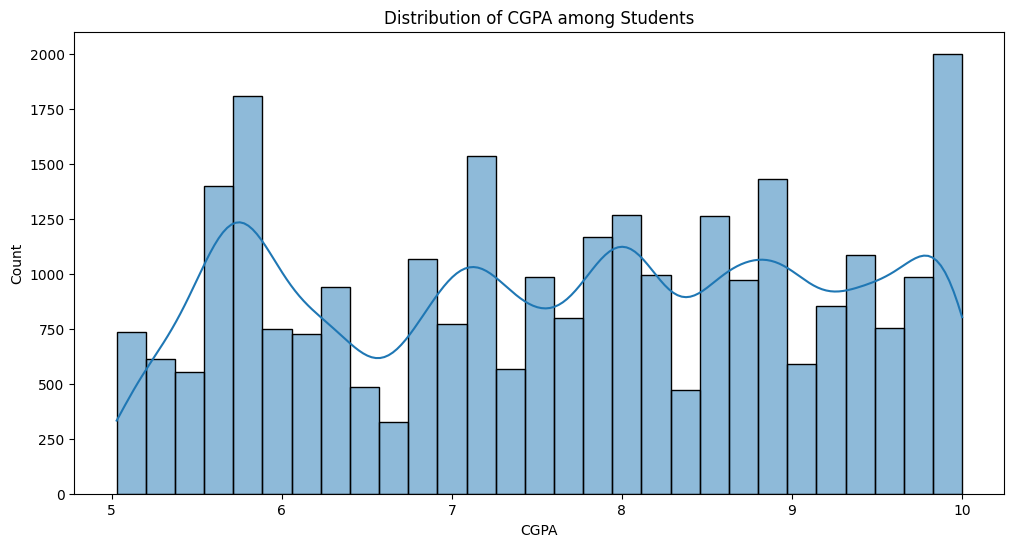

In [27]:
# Distribution of CGPA among Students
student_cgpa = train[train['Working Professional or Student'] == 0]['CGPA'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.histplot(train[train['Working Professional or Student'] == 0]['CGPA'].dropna(), kde=True)
plt.title("Distribution of CGPA among Students")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

In [28]:
# Fill missing CGPA with KNN imputation for students
imputer = KNNImputer(n_neighbors=11)
train_students = train[train['Working Professional or Student'] == 0]
test_students = test[test['Working Professional or Student'] == 0]

# Apply KNN imputer only on numerical columns
train_students_imputed = imputer.fit_transform(train_students.select_dtypes(include=['float64', 'int64']))
test_students_imputed = imputer.fit_transform(test_students.select_dtypes(include=['float64', 'int64']))

# Only update the CGPA column
train.loc[train['Working Professional or Student'] == 0, 'CGPA'] = train_students_imputed[:, train_students.columns.get_loc('CGPA')]
test.loc[test['Working Professional or Student'] == 0, 'CGPA'] = test_students_imputed[:, test_students.columns.get_loc('CGPA')]

# Double check
print(f"Remaining missing values in train: {train['CGPA'].isnull().sum()}")
print(f"Remaining missing values in test: {test['CGPA'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


### `Study Satisfaction` and `Job Satisfaction`

<Figure size 1200x600 with 0 Axes>

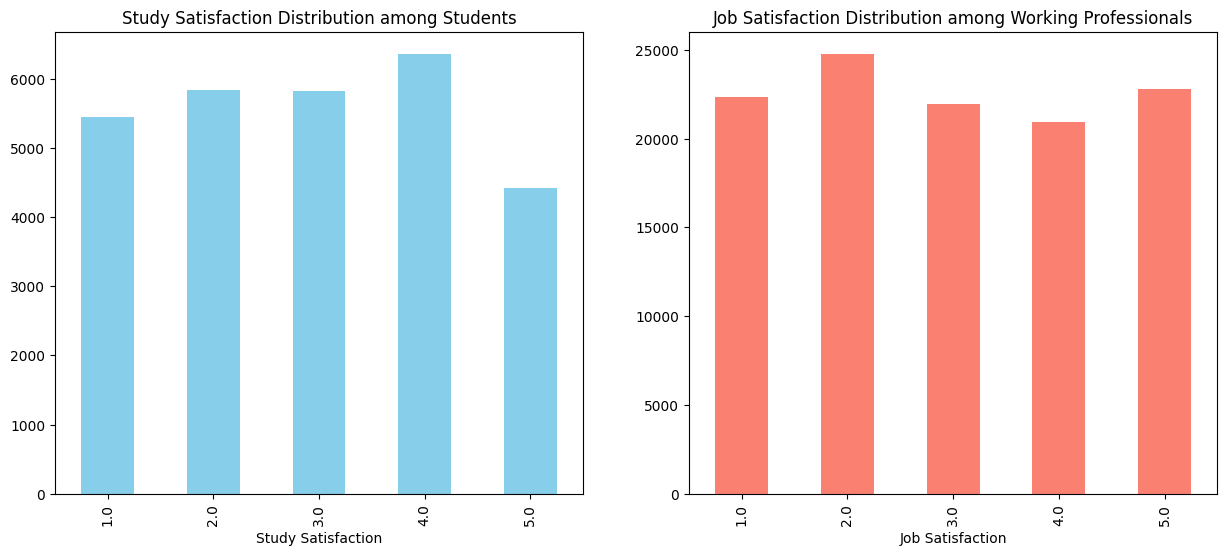

In [29]:
# Distribution of Study Satisfaction among Students and Job Satisfaction among Working Professionals
student_study_satisfaction = train[train['Working Professional or Student'] == 0]['Study Satisfaction'].value_counts().sort_index()
working_job_satisfaction = train[train['Working Professional or Student'] == 1]['Job Satisfaction'].value_counts().sort_index()

plt.figure(figsize=(12,6))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
student_study_satisfaction.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Study Satisfaction Distribution among Students")
working_job_satisfaction.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("Job Satisfaction Distribution among Working Professionals")

plt.show()

In [30]:
# Fill both Study Satisfaction and Job Satisfaction with mode imputation
mode_study_satisfaction = train[train['Working Professional or Student'] == 0]['Study Satisfaction'].mode()[0]
train.loc[(train['Working Professional or Student'] == 0) & (train['Study Satisfaction'].isnull()), 'Study Satisfaction'] = mode_study_satisfaction
test.loc[(test['Working Professional or Student'] == 0) & (test['Study Satisfaction'].isnull()), 'Study Satisfaction'] = mode_study_satisfaction

mode_job_satisfaction = train[train['Working Professional or Student'] == 1]['Job Satisfaction'].mode()[0]
train.loc[(train['Working Professional or Student'] == 1) & (train['Job Satisfaction'].isnull()), 'Job Satisfaction'] = mode_job_satisfaction
test.loc[(test['Working Professional or Student'] == 1) & (test['Job Satisfaction'].isnull()), 'Job Satisfaction'] = mode_job_satisfaction

# Double check
print("Remaining missing values in train:")
print(train[['Study Satisfaction', 'Job Satisfaction']].isnull().sum())
print("Remaining missing values in test:")
print(test[['Study Satisfaction', 'Job Satisfaction']].isnull().sum())

Remaining missing values in train:
Study Satisfaction    0
Job Satisfaction      0
dtype: int64
Remaining missing values in test:
Study Satisfaction    0
Job Satisfaction      0
dtype: int64


### `Sleep Duration`

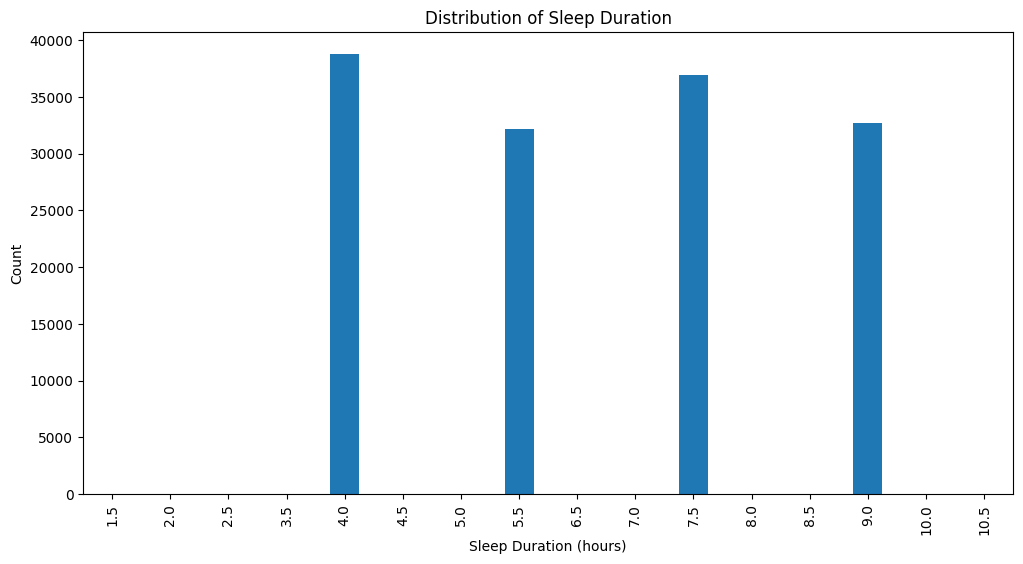

In [31]:
# Distribution of Sleep Duration
sleep_duration = train['Sleep Duration'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sleep_duration.plot(kind='bar')
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Count")
plt.show()

In [32]:
# Weighted Random sample imputation for Sleep Duration to preserve distribution
np.random.seed(42) # For reproducibility

for dataset in [train, test]:
    # Find missing values
    sleep_missing = dataset['Sleep Duration'].isnull()
    n_missing = sleep_missing.sum()
    
    # Calculate weights based on original distribution
    sleep_values = dataset['Sleep Duration'].dropna()
    value_counts = sleep_values.value_counts(normalize=True).sort_index()
    unique_sleep_values = value_counts.index.values
    probs = value_counts.values
    
    # Perform weighted random sampling
    imputed_values = np.random.choice(unique_sleep_values, size=n_missing, p=probs, replace=True)
    dataset.loc[sleep_missing, 'Sleep Duration'] = imputed_values
    
# Double check
print(f"Remaining missing values in train: {train['Sleep Duration'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Sleep Duration'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


### `Dietary Habits`

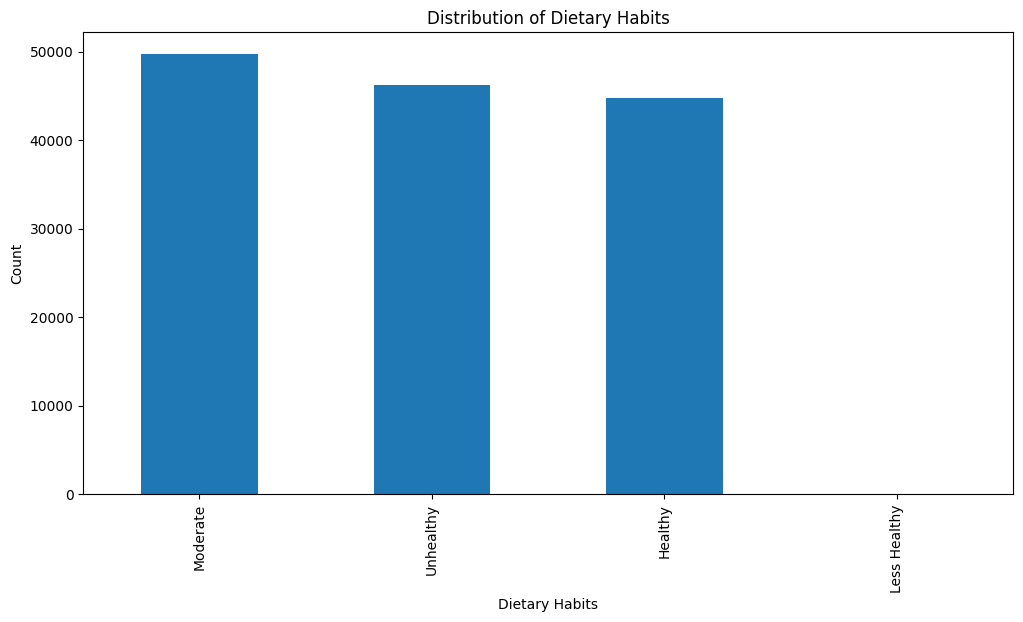

In [33]:
# Distribution of Dietary Habits
dietary_habits = train['Dietary Habits'].value_counts()
plt.figure(figsize=(12,6))
dietary_habits.plot(kind='bar')
plt.title("Distribution of Dietary Habits")
plt.xlabel("Dietary Habits")
plt.ylabel("Count")
plt.show()

In [34]:
# Fill missing Dietary Habits with mode imputation
mode_dietary_habits = train['Dietary Habits'].mode()[0]
train.fillna({'Dietary Habits': mode_dietary_habits}, inplace=True)
test.fillna({'Dietary Habits': mode_dietary_habits}, inplace=True)

# Double check
print(f"Remaining missing values in train: {train['Dietary Habits'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Dietary Habits'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


### `Degree`

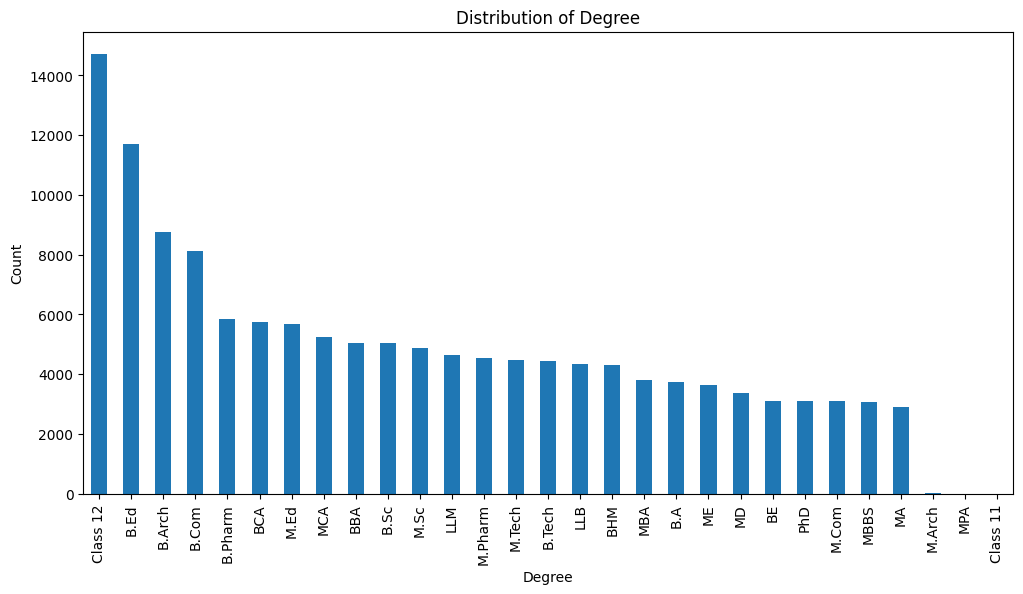

In [35]:
# Distribution of Degree
degree = train['Degree'].value_counts()
plt.figure(figsize=(12,6))
degree.plot(kind='bar')
plt.title("Distribution of Degree")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

In [36]:
# Fill missing Degree using KNN imputation 
imputer = KNNImputer(n_neighbors=11)
train_copy = train.copy()
test_copy = test.copy()

# Encode categorical features before KNN imputation
train_encoded = pd.get_dummies(train_copy.select_dtypes(include=['object']), drop_first=True)
test_encoded = pd.get_dummies(test_copy.select_dtypes(include=['object']), drop_first=True)

# Align columns in train and test
train_encoded, test_encoded = train_encoded.align(test_encoded, join='outer', axis=1, fill_value=0)

# Combine encoded categorical features with numerical features
train_numerical = train_copy.select_dtypes(include=['float64', 'int64'])
test_numerical = test_copy.select_dtypes(include=['float64', 'int64'])
train_for_imputation = pd.concat([train_numerical, train_encoded], axis=1)
test_for_imputation = pd.concat([test_numerical, test_encoded], axis=1)

# Apply KNN imputer
train_imputed = imputer.fit_transform(train_for_imputation)
test_imputed = imputer.fit_transform(test_for_imputation)

# Only update the Degree column
degree_col_index = list(train_for_imputation.columns).index('Degree_' + train['Degree'].mode()[0])
train.loc[train['Degree'].isnull(), 'Degree'] = train_imputed[train['Degree'].isnull(), degree_col_index]
test.loc[test['Degree'].isnull(), 'Degree'] = test_imputed[test['Degree'].isnull(), degree_col_index]

# Double check
print(f"Remaining missing values in train: {train['Degree'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Degree'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


### `Financial Stress`

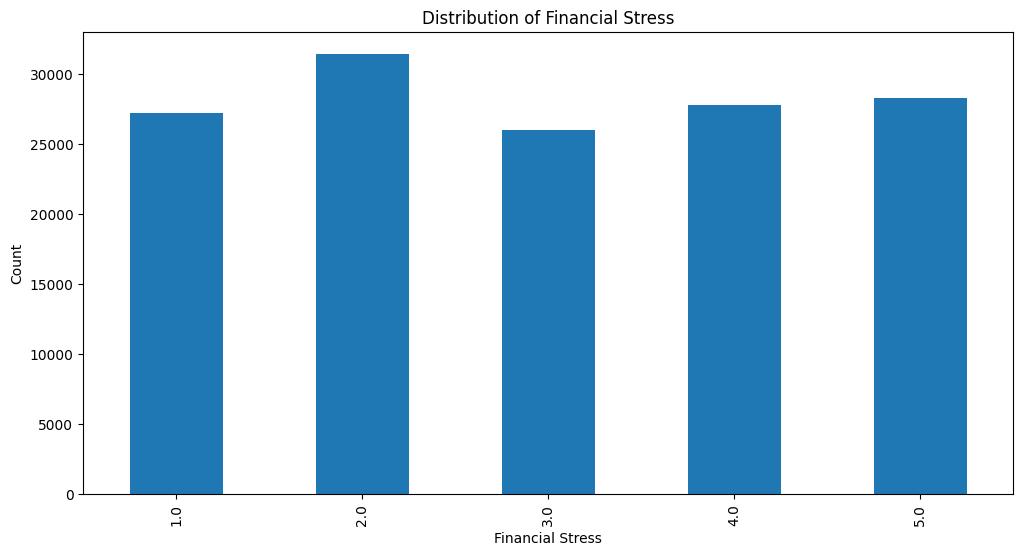

In [37]:
# Distribution of Financial Stress
financial_stress = train['Financial Stress'].value_counts().sort_index()
plt.figure(figsize=(12,6))
financial_stress.plot(kind='bar')
plt.title('Distribution of Financial Stress')
plt.xlabel('Financial Stress')
plt.ylabel('Count')
plt.show()

In [38]:
# Fill missing Financial Stress with median imputation
median_financial_stress = int(train['Financial Stress'].median())
train.fillna({'Financial Stress': median_financial_stress}, inplace=True)
test.fillna({'Financial Stress': median_financial_stress}, inplace=True)

# Double check
print(f"Remaining missing values in train: {train['Financial Stress'].isnull().sum()}")
print(f"Remaining missing values in test: {test['Financial Stress'].isnull().sum()}")

Remaining missing values in train: 0
Remaining missing values in test: 0


In [39]:
# Check missing values in the two datasets again
print("Missing values in training set after imputation:\n", train.isnull().sum())
print("\nMissing values in test set after imputation:\n", test.isnull().sum())

Missing values in training set after imputation:
 id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

Missing values in test set after imputation:
 id                            

## Obligatory check for duplicate rows

In [40]:
# Check duplicate rows in the training set
duplicate_rows = train.duplicated().sum()
print(f"Number of duplicate rows in the training set: {duplicate_rows}")

Number of duplicate rows in the training set: 0


## Feature Engineering

### `Overall Stress Level`

A new feature calculated using the different stress and satisfaction levels provided in the dataset. This one aims to provide a more holistic view of an individual's stress level by combining various related factors into a single metric. The formula is as follows:

$$\text{Overall Stress Level} = \text{Academic Pressure} + \text{Work Pressure} - \text{Study Satisfaction} - \text{Job Satisfaction} + \text{Financial Stress}$$

After the preprocessing steps, Students will all have `Work Pressure` and `Job Satisfaction` set to 0, while Working Professionals will have `Academic Pressure` and `Study Satisfaction` set to 0. This ensures that the Overall Stress Level accurately reflects the stressors relevant to each group.

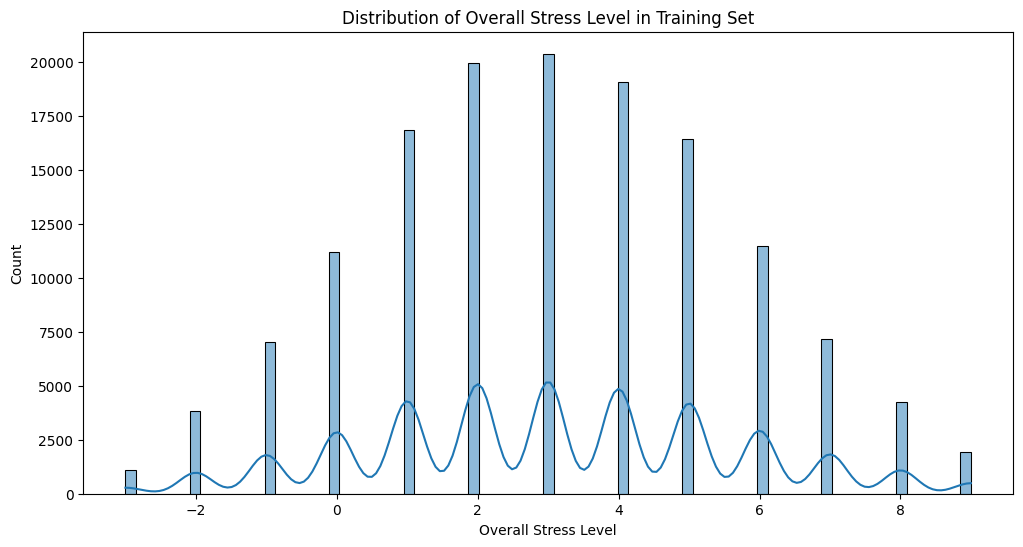

In [41]:
# Create new feature 'Overall Stress Level'
train['Overall Stress Level'] = (train['Academic Pressure'] + train['Work Pressure'] - train['Study Satisfaction'] - train['Job Satisfaction'] + train['Financial Stress'])
test['Overall Stress Level'] = (test['Academic Pressure'] + test['Work Pressure'] - test['Study Satisfaction'] - test['Job Satisfaction'] + test['Financial Stress'])

# Distribution of Overall Stress Level in training set
plt.figure(figsize=(12,6))
sns.histplot(train['Overall Stress Level'], kde=True)
plt.title('Distribution of Overall Stress Level in Training Set')
plt.xlabel('Overall Stress Level')
plt.ylabel('Count')
plt.show()

In [42]:
# Move `Depression` back to the end of the training dataframe
depression_train = train.pop('Depression')
train['Depression'] = depression_train

## Save Processed Data

In [43]:
# View processed training data
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,...,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Overall Stress Level,Depression
0,0,Aaradhya,0,49.0,Ludhiana,1,Chef,0.0,5.0,0.0,...,2.0,9.0,Healthy,BHM,0,1.0,2.0,0,5.0,0
1,1,Vivan,1,26.0,Varanasi,1,Teacher,0.0,4.0,0.0,...,3.0,4.0,Unhealthy,LLB,1,7.0,3.0,0,4.0,1
2,2,Yuvraj,1,33.0,Visakhapatnam,0,Not Applicable,5.0,0.0,5.5,...,0.0,5.5,Healthy,B.Pharm,1,3.0,1.0,0,4.0,1
3,3,Yuvraj,1,22.0,Mumbai,1,Teacher,0.0,5.0,0.0,...,1.0,4.0,Moderate,BBA,1,10.0,1.0,1,5.0,1
4,4,Rhea,0,30.0,Kanpur,1,Business Analyst,0.0,1.0,0.0,...,1.0,5.5,Unhealthy,BBA,1,9.0,4.0,1,4.0,0


In [44]:
# Save processed datasets
train.to_csv('../data/processed_train.csv', index=False)
test.to_csv('../data/processed_test.csv', index=False)